# 13 — RNN, LSTM, BPTT et écrêtage du gradient

La tâche reste une classification séquentielle plusieurs-vers-un : 960 mesures successives et 6 canaux produisent une seule classe binaire. Toutes les fenêtres possèdent une longueur fixe de 960 pas temporels. Aucun padding ni masque n'est donc nécessaire dans cette expérience.

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import *
from src.helpers import count_parameters, set_seed

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Périphérique sélectionné :", device)
print("CUDA disponible :", torch.cuda.is_available())

Périphérique sélectionné : cuda
CUDA disponible : True


## Rétropropagation à travers le temps

Un RNN simple calcule

\[
h_t=\phi(W_{xh}x_t+W_{hh}h_{t-1}+b_h),\qquad z=W_{hy}h_{960}+b_y.
\]

Le réseau est conceptuellement déplié sur 960 pas. BPTT applique la règle de dérivation en chaîne depuis la perte vers chaque état antérieur. Une contribution au gradient contient des produits répétés de Jacobiennes récurrentes,

\[
\frac{\partial h_T}{\partial h_t}=\prod_{k=t+1}^{T}\frac{\partial h_k}{\partial h_{k-1}}.
\]

Si leurs valeurs singulières effectives restent inférieures à un, ce produit tend vers zéro (gradient évanescent) ; si elles sont durablement supérieures à un, il peut croître brutalement (gradient explosif). Les portes d'entrée, d'oubli et de sortie du LSTM, ainsi que son chemin de cellule mémoire, peuvent faciliter la conservation d'information sur une longue portée, sans garantir la généralisation.

L'écrêtage par norme remplace un gradient trop grand par une version remise à l'échelle. Il limite les mises à jour excessives et peut stabiliser l'optimisation. Il ne restaure pas un gradient déjà évanescent et ne résout ni le déséquilibre de classes ni la variabilité inter-sujets.

## Inspection et comparaison équitable

In [9]:
from src.models import LSTMClassifier, SimpleRNNClassifier
from src.training import compute_global_gradient_norm

HIDDEN_SIZE = 32
rnn = SimpleRNNClassifier(input_size=6, hidden_size=HIDDEN_SIZE).to(device)
lstm = LSTMClassifier(input_size=6, hidden_size=HIDDEN_SIZE).to(device)
inspection = pd.DataFrame([
    {"model": "RNN", "hidden size": rnn.rnn.hidden_size, "layers": rnn.rnn.num_layers, "bidirectional": rnn.rnn.bidirectional, "parameters": count_parameters(rnn)},
    {"model": "LSTM", "hidden size": lstm.lstm.hidden_size, "layers": lstm.lstm.num_layers, "bidirectional": lstm.lstm.bidirectional, "parameters": count_parameters(lstm)},
])
display(inspection)
toy = torch.randn(2, 960, 6, device=device)
assert rnn(toy).shape == lstm(toy).shape == (2, 1)
assert next(rnn.parameters()).device == toy.device
print("Périphérique modèle :", next(rnn.parameters()).device, "| lot :", toy.device)

,model,hidden size,layers,bidirectional,parameters
0,RNN,32,1,False,1825
1,LSTM,32,1,False,6209


Périphérique modèle : cuda:0 | lot : cuda:0


Les deux cœurs utilisent ici la même taille cachée, une couche, le même sens, les mêmes fenêtres normalisées, lots, optimiseur, taux, régularisation, patience, seuil de validation et graine. Le LSTM possède davantage de paramètres à cause de ses portes. Les sorties sont des logits bruts et la perte est `BCEWithLogitsLoss`.

In [10]:
from torch.utils.data import TensorDataset
from src.experiments import run_validation_selected_experiment

sequence_dir = PROJECT_ROOT / "data/processed/sequence"
metadata_dir = PROJECT_ROOT / "data/processed/metadata"

def load_sequence_datasets():
    return tuple(TensorDataset(
        torch.load(sequence_dir / f"X_{split}.pt", map_location="cpu", weights_only=True),
        torch.load(sequence_dir / f"y_{split}.pt", map_location="cpu", weights_only=True),
    ) for split in ("train", "validation", "test"))

datasets = load_sequence_datasets() if (sequence_dir / "X_train.pt").exists() else None
validation_meta = pd.read_csv(metadata_dir / "windows_validation.csv") if datasets else None
test_meta = pd.read_csv(metadata_dir / "windows_test.csv") if datasets else None

## RNN sans écrêtage contre RNN avec norme maximale 1,0

In [11]:
RUN_CLIPPING_EXPERIMENT = False
clipping_results = {}
if RUN_CLIPPING_EXPERIMENT:
    common = {
        "model_class": "SimpleRNNClassifier", "architecture": {"input_size": 6, "hidden_size": HIDDEN_SIZE, "layers": 1, "bidirectional": False},
        "seed": RANDOM_SEED, "subject_split": SPLIT_SUBJECTS, "input_channels": SEQUENCE_CHANNELS,
        "input_shape": [960, 6], "normalization_statistics": "artifacts/preprocessing/sequence_scaler.joblib",
    }
    for name, clip in [("without_clipping", None), ("clip_norm_1", 1.0)]:
        try:
            clipping_results[name] = run_validation_selected_experiment(
                lambda: SimpleRNNClassifier(input_size=6, hidden_size=HIDDEN_SIZE), datasets,
                validation_meta, test_meta, PROJECT_ROOT / "artifacts/models/rnn_clipping" / name,
                common, device, compare_weighted_loss=False, gradient_clip=clip,
                record_gradient_norms=True, record_validation_macro_f1=True,
            )
        except (FloatingPointError, RuntimeError) as error:
            failure_dir = PROJECT_ROOT / "artifacts/models/rnn_clipping" / name
            failure_dir.mkdir(parents=True, exist_ok=True)
            with open(failure_dir / "numerical_failure.json", "w", encoding="utf-8") as handle:
                json.dump({"numerically_stable": False, "error": str(error)}, handle, indent=2)
            print(name, "arrêté honnêtement :", error)
else:
    print("Non exécuté : activer RUN_CLIPPING_EXPERIMENT pour l'expérience réelle.")

Non exécuté : activer RUN_CLIPPING_EXPERIMENT pour l'expérience réelle.


## Tracés obligatoires

In [12]:
figure_dir = PROJECT_ROOT / "reports/figures/rnn_gradient_clipping"
figure_dir.mkdir(parents=True, exist_ok=True)
history_paths = {
    "sans écrêtage": PROJECT_ROOT / "artifacts/models/rnn_clipping/without_clipping/training_history.csv",
    "norme max = 1.0": PROJECT_ROOT / "artifacts/models/rnn_clipping/clip_norm_1/training_history.csv",
}
histories = {name: pd.read_csv(path) for name, path in history_paths.items() if path.exists()}

def plot_metric(column, title, ylabel, filename):
    if not histories: return
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, frame in histories.items():
        if column in frame: ax.plot(frame.epoch, frame[column], label=name)
    ax.set(title=title, xlabel="Époque", ylabel=ylabel); ax.legend(); fig.tight_layout()
    fig.savefig(figure_dir / filename, dpi=150); plt.show()

plot_metric("train_loss", "Perte d'entraînement", "BCE", "training_loss.png")
plot_metric("validation_loss", "Perte de validation", "BCE", "validation_loss.png")
plot_metric("validation_macro_f1", "Macro-F1 de validation", "Macro-F1", "validation_macro_f1.png")
plot_metric("gradient_pre_max", "Norme pré-écrêtage maximale", "Norme L2", "gradient_pre_max.png")
plot_metric("gradient_pre_median", "Norme pré-écrêtage médiane", "Norme L2", "gradient_pre_median.png")
if "norme max = 1.0" in histories:
    clipped = histories["norme max = 1.0"]
    fig, ax = plt.subplots(figsize=(7, 4)); ax.plot(clipped.epoch, clipped.gradient_pre_mean, label="avant"); ax.plot(clipped.epoch, clipped.gradient_post_mean, label="après")
    ax.set(title="Normes moyennes avant/après écrêtage", xlabel="Époque", ylabel="Norme L2"); ax.legend(); fig.tight_layout(); fig.savefig(figure_dir / "pre_vs_post.png", dpi=150); plt.show()

## RNN contre LSTM et rechargement du RNN final

In [13]:
RUN_FAIR_RNN_LSTM = False
fair_results = {}
if RUN_FAIR_RNN_LSTM:
    common = {"seed": RANDOM_SEED, "subject_split": SPLIT_SUBJECTS, "input_channels": SEQUENCE_CHANNELS, "input_shape": [960, 6], "normalization_statistics": "artifacts/preprocessing/sequence_scaler.joblib"}
    for name, factory in {
        "rnn_fair": lambda: SimpleRNNClassifier(input_size=6, hidden_size=HIDDEN_SIZE),
        "lstm_fair": lambda: LSTMClassifier(input_size=6, hidden_size=HIDDEN_SIZE),
    }.items():
        fair_results[name] = run_validation_selected_experiment(factory, datasets, validation_meta, test_meta,
            PROJECT_ROOT / "artifacts/models" / name,
            {**common, "model_class": name, "architecture": {"hidden_size": HIDDEN_SIZE, "layers": 1, "bidirectional": False}},
            device, compare_weighted_loss=True)
    rows = []
    for name, result in fair_results.items():
        rows.append({"model": name, "parameters": count_parameters(result["model"]),
            "validation macro F1": result["validation_metrics"]["macro_f1"], "test macro F1": result["test_metrics"]["macro_f1"],
            "weighted F1": result["test_metrics"]["weighted_f1"], "stress precision": result["test_metrics"]["stress_precision"],
            "stress recall": result["test_metrics"]["stress_recall"], "ROC-AUC": result["test_metrics"]["roc_auc"],
            "average precision": result["test_metrics"]["average_precision"], "best epoch": result["training_summary"]["best_epoch"],
            "training time": result["training_summary"]["training_time_seconds"], "inference time": result["test_metrics"]["inference_time_seconds"]})
    display(pd.DataFrame(rows))

    final_rnn = fair_results["rnn_fair"]["model"].eval(); batch = datasets[2].tensors[0][:4].to(device)
    with torch.no_grad(): before = final_rnn(batch)
    reloaded = SimpleRNNClassifier(input_size=6, hidden_size=HIDDEN_SIZE).to(device)
    reloaded.load_state_dict(torch.load(PROJECT_ROOT / "artifacts/models/rnn_fair/best_model.pt", map_location=device, weights_only=True)); reloaded.eval()
    with torch.no_grad(): after = reloaded(batch)
    torch.testing.assert_close(before, after)

## Analyse d'échec fondée sur les artefacts

Une prédiction quasi constante « non-stress » doit être vérifiée par la matrice de confusion, la distribution des classes prédites, précision/rappel stress, rappel par sujet et distributions de probabilités conditionnelles. Les 960 pas récurrents, l'évanescence du gradient, le déséquilibre, la variabilité des participants, les quinze participants indépendants, l'emploi du seul état final et le surapprentissage à des motifs propres aux sujets sont des hypothèses, pas des causes établies sans expérience dédiée.

Distribution prédite :
 predicted_label
0    0.992958
1    0.007042
Name: proportion, dtype: float64
Matrice de confusion :
 predicted_label    0  1
true_label             
0                297  1
1                126  2


,subject_id,stress_recall
0,S11,0.045455
1,S14,0.000000
2,S2,0.000000


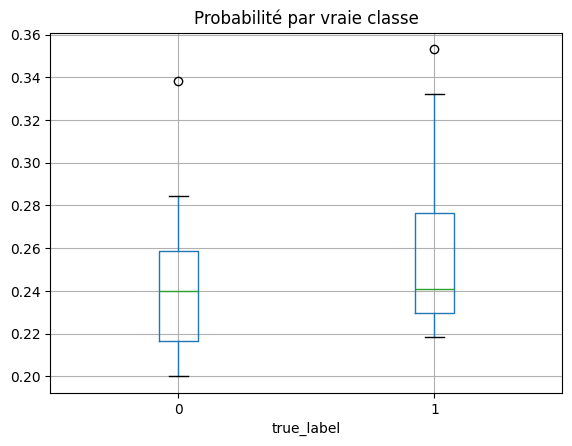

In [14]:
rnn_dir = PROJECT_ROOT / "artifacts/models/rnn_fair"
if not (rnn_dir / "test_predictions.csv").exists(): rnn_dir = PROJECT_ROOT / "artifacts/models/rnn"
if (rnn_dir / "test_predictions.csv").exists():
    predictions = pd.read_csv(rnn_dir / "test_predictions.csv")
    print("Distribution prédite :\n", predictions.predicted_label.value_counts(normalize=True).sort_index())
    print("Matrice de confusion :\n", pd.crosstab(predictions.true_label, predictions.predicted_label))
    per_subject = pd.read_csv(rnn_dir / "per_subject_metrics.csv")
    display(per_subject[["subject_id", "stress_recall"]])
    predictions.boxplot(column="stress_probability", by="true_label"); plt.suptitle(""); plt.title("Probabilité par vraie classe"); plt.show()